# Recommender experiment analysis scaffold

This notebook is the **entry point** for the analysis of one recommender experiment. It is designed as a stable base that can be extended throughout the project.

Current scope:
- load one experiment with iterations `1..5`
- standardize and join all relevant tables
- compute basic statistics for users, items, interactions, recommendations, accepted songs, metrics, and embeddings
- expose a few compact diagnostics that are useful before moving to visual analytics and steering

Expected folder structure:

```text
experiments/
  babyLFM2b1k/
    input/
      dataset.inter
      demographics.tsv
      tracks.tsv
    datasets/
      iteration_1.inter
      ...
      iteration_6.inter
    output/
      iteration_1_top_k.tsv
      iteration_1_accepted_songs.tsv
      iteration_1_ndcg_per_user.tsv
      iteration_1_user_embedding.pt
      iteration_1_item_embedding.pt
      ...
    metrics.csv
    user_based_metrics.csv
    baselines.csv
    params.json
```

**Design principle:** all loaders are robust to missing files and return harmonized column names.

In [140]:
from __future__ import annotations

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import torch
except ImportError:
    torch = None

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

## 1. Configuration

Adjust `EXPERIMENT_ROOT` if needed.  
When this notebook is placed in `experiments/analysis/notebooks/`, the default relative path should work.

In [141]:
# --- primary experiment path ---
EXPERIMENT_ROOT = Path("../babyLFM2b1k").resolve()

# --- optional fallback for ad-hoc testing outside the project tree ---
# Set this only if you want to test the notebook against copied example files.
FALLBACK_ROOT = None  # e.g., Path("/mnt/data")

MAX_ITERATION = 5
TOP_K_EXPECTED = 10

print("Experiment root:", EXPERIMENT_ROOT)
print("Exists:", EXPERIMENT_ROOT.exists())

Experiment root: C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k
Exists: True


## 2. Path resolution

In [142]:
def resolve_existing_path(*candidates: Path | None) -> Path:
    for c in candidates:
        if c is not None and Path(c).exists():
            return Path(c)
    raise FileNotFoundError(f"None of the candidate paths exists: {candidates}")

def experiment_file(rel_path: str) -> Path:
    primary = EXPERIMENT_ROOT / rel_path
    fallback = Path(FALLBACK_ROOT) / Path(rel_path).name if FALLBACK_ROOT is not None else None
    return resolve_existing_path(primary, fallback)

input_dir = resolve_existing_path(
    EXPERIMENT_ROOT / "input",
    FALLBACK_ROOT if FALLBACK_ROOT is not None else None,
)
output_dir = EXPERIMENT_ROOT / "output"
datasets_dir = EXPERIMENT_ROOT / "datasets"

print("input_dir   :", input_dir)
print("output_dir  :", output_dir if output_dir.exists() else "(missing)")
print("datasets_dir:", datasets_dir if datasets_dir.exists() else "(missing)")

input_dir   : C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\input
output_dir  : C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\output
datasets_dir: C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\datasets


## 3. Loader utilities

The experiment mixes header/no-header formats and two naming conventions:
- `user_id`, `item_id`
- `user_id:token`, `item_id:token`

The helpers below standardize both to:
- `user_id`
- `item_id`

In [143]:
DEMOGRAPHICS_COLS = ["country", "age", "gender", "user_id"]
TRACKS_COLS = ["track_id", "artist", "title", "artist_country", "artist_gender"]

def standardize_interaction_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        "user_id:token": "user_id",
        "item_id:token": "item_id",
        "track_id": "item_id",
    }
    out = df.rename(columns=rename_map).copy()
    for col in ["user_id", "item_id"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").astype("Int64")
    return out

def load_demographics(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, names=DEMOGRAPHICS_COLS)
    df["user_id"] = pd.to_numeric(df["user_id"], errors="coerce").astype("Int64")
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    return df

def load_tracks(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, names=TRACKS_COLS)
    df["track_id"] = pd.to_numeric(df["track_id"], errors="coerce").astype("Int64")
    return df.rename(columns={"track_id": "item_id"})

def load_interactions(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    return standardize_interaction_columns(df)

def load_top_k(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    df["user_id"] = pd.to_numeric(df["user_id"], errors="coerce").astype("Int64")
    df["item_id"] = pd.to_numeric(df["item_id"], errors="coerce").astype("Int64")
    df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    return df

def load_ndcg(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    df["user_id"] = pd.to_numeric(df["user_id"], errors="coerce").astype("Int64")
    ndcg_col = [c for c in df.columns if "ndcg" in c.lower()][0]
    df = df.rename(columns={ndcg_col: "ndcg_at_10"})
    df["ndcg_at_10"] = pd.to_numeric(df["ndcg_at_10"], errors="coerce")
    return df

def load_csv_if_exists(path: Path) -> pd.DataFrame | None:
    return pd.read_csv(path) if path.exists() else None

def load_pt_if_exists(path: Path):
    if (not path.exists()) or (torch is None):
        return None
    return torch.load(path, map_location="cpu")

## 4. Load static metadata

In [144]:
demographics = load_demographics(experiment_file("input/demographics.tsv") if (EXPERIMENT_ROOT / "input").exists() else experiment_file("demographics.tsv"))
tracks = load_tracks(experiment_file("input/tracks.tsv") if (EXPERIMENT_ROOT / "input").exists() else experiment_file("tracks.tsv"))
dataset_input = load_interactions(experiment_file("input/dataset.inter") if (EXPERIMENT_ROOT / "input").exists() else experiment_file("dataset.inter"))

params_path_candidates = [
    EXPERIMENT_ROOT / "params.json",
    Path(FALLBACK_ROOT) / "params.json" if FALLBACK_ROOT is not None else None,
]
params = {}
for p in params_path_candidates:
    if p is not None and p.exists():
        params = json.loads(Path(p).read_text())
        break

print("demographics:", demographics.shape)
print("tracks      :", tracks.shape)
print("dataset     :", dataset_input.shape)
print("params      :", params)

demographics: (655, 4)
tracks      : (991, 5)
dataset     : (14620, 2)
params      : {'dataset_name': 'babyLFM2b1k', 'iteration': 1, 'model': 'BPR', 'choice_model': 'consume_all', 'config': 'recbole_config_default.yaml'}


In [145]:
display(demographics.head())
display(tracks.head())
display(dataset_input.head())

,country,age,gender,user_id
0,NL,37,m,0
1,FI,35,m,1
2,UK,42,m,2
3,US,27,m,3
4,DE,27,m,4


,item_id,artist,title,artist_country,artist_gender
0,0,shakewell,.38 Special,US,Male
1,1,Ten Typ Mes,100 wymówek,PL,Male
2,2,Marilyn Manson,1996,US,Male
3,3,Tinashe,2 On,US,Female
4,4,Ann Lee,2 Times,IT,Female


,user_id,item_id
0,356,322
1,129,827
2,202,619
3,202,619
4,261,384


## 5. Discover and load iteration-wise files

The notebook loads all available files up to `MAX_ITERATION`.  
Each file family is stored in a dictionary indexed by iteration.

In [146]:
def get_iteration_path(iteration: int, kind: str) -> Path | None:
    # Preferred project layout
    preferred = {
        "dataset": EXPERIMENT_ROOT / "datasets" / f"iteration_{iteration}.inter",
        "top_k": EXPERIMENT_ROOT / "output" / f"iteration_{iteration}_top_k.tsv",
        "accepted": EXPERIMENT_ROOT / "output" / f"iteration_{iteration}_accepted_songs.tsv",
        "ndcg": EXPERIMENT_ROOT / "output" / f"iteration_{iteration}_ndcg_per_user.tsv",
        "user_embedding": EXPERIMENT_ROOT / "output" / f"iteration_{iteration}_user_embedding.pt",
        "item_embedding": EXPERIMENT_ROOT / "output" / f"iteration_{iteration}_item_embedding.pt",
    }
    # Fallback flat layout for uploaded examples
    fallback = {
        "dataset": Path(FALLBACK_ROOT) / f"iteration_{iteration}.inter" if FALLBACK_ROOT is not None else None,
        "top_k": Path(FALLBACK_ROOT) / f"iteration_{iteration}_top_k.tsv" if FALLBACK_ROOT is not None else None,
        "accepted": Path(FALLBACK_ROOT) / f"iteration_{iteration}_accepted_songs.tsv" if FALLBACK_ROOT is not None else None,
        "ndcg": Path(FALLBACK_ROOT) / f"iteration_{iteration}_ndcg_per_user.tsv" if FALLBACK_ROOT is not None else None,
        "user_embedding": Path(FALLBACK_ROOT) / f"iteration_{iteration}_user_embedding.pt" if FALLBACK_ROOT is not None else None,
        "item_embedding": Path(FALLBACK_ROOT) / f"iteration_{iteration}_item_embedding.pt" if FALLBACK_ROOT is not None else None,
    }

    for candidate in [preferred[kind], fallback[kind]]:
        if candidate is not None and candidate.exists():
            return candidate
    return None


datasets_by_iter = {}
topk_by_iter = {}
accepted_by_iter = {}
ndcg_by_iter = {}
user_emb_by_iter = {}
item_emb_by_iter = {}

for t in range(1, MAX_ITERATION + 1):
    p = get_iteration_path(t, "dataset")
    if p is not None:
        df = load_interactions(p)
        df["iteration"] = t
        datasets_by_iter[t] = df

    p = get_iteration_path(t, "top_k")
    if p is not None:
        df = load_top_k(p)
        df["iteration"] = t
        topk_by_iter[t] = df

    p = get_iteration_path(t, "accepted")
    if p is not None:
        df = load_interactions(p)
        df["iteration"] = t
        accepted_by_iter[t] = df

    p = get_iteration_path(t, "ndcg")
    if p is not None:
        df = load_ndcg(p)
        df["iteration"] = t
        ndcg_by_iter[t] = df

    p = get_iteration_path(t, "user_embedding")
    if p is not None:
        user_emb_by_iter[t] = load_pt_if_exists(p)

    p = get_iteration_path(t, "item_embedding")
    if p is not None:
        item_emb_by_iter[t] = load_pt_if_exists(p)

available_iterations = sorted(set(datasets_by_iter) | set(topk_by_iter) | set(accepted_by_iter) | set(ndcg_by_iter) | set(user_emb_by_iter) | set(item_emb_by_iter))
print("Available iterations:", available_iterations)

Available iterations: [1, 2, 3, 4, 5]


## 6. Concatenate dynamic tables

In [147]:
datasets_all = pd.concat(datasets_by_iter.values(), ignore_index=True) if datasets_by_iter else pd.DataFrame(columns=["user_id", "item_id", "iteration"])
topk_all = pd.concat(topk_by_iter.values(), ignore_index=True) if topk_by_iter else pd.DataFrame(columns=["user_id", "item_id", "rank", "score", "iteration"])
accepted_all = pd.concat(accepted_by_iter.values(), ignore_index=True) if accepted_by_iter else pd.DataFrame(columns=["user_id", "item_id", "iteration"])
ndcg_all = pd.concat(ndcg_by_iter.values(), ignore_index=True) if ndcg_by_iter else pd.DataFrame(columns=["user_id", "ndcg_at_10", "iteration"])

print("datasets_all:", datasets_all.shape)
print("topk_all    :", topk_all.shape)
print("accepted_all:", accepted_all.shape)
print("ndcg_all    :", ndcg_all.shape)

datasets_all: (138590, 3)
topk_all    : (32750, 5)
accepted_all: (32750, 3)
ndcg_all    : (3275, 3)


## 7. Static dataset summary

In [148]:
n_users = demographics["user_id"].nunique()
n_items = tracks["item_id"].nunique()
n_interactions = len(dataset_input)
n_unique_pairs = dataset_input[["user_id", "item_id"]].drop_duplicates().shape[0]
dup_ratio = 1 - (n_unique_pairs / n_interactions)

static_summary = pd.DataFrame({
    "n_users": [n_users],
    "n_items": [n_items],
    "n_interactions_input": [n_interactions],
    "n_unique_user_item_pairs": [n_unique_pairs],
    "duplicate_interaction_ratio": [dup_ratio],
    "mean_interactions_per_user": [n_interactions / n_users],
    "mean_interactions_per_item": [n_interactions / n_items],
})

display(static_summary.round(4))

,n_users,n_items,n_interactions_input,n_unique_user_item_pairs,duplicate_interaction_ratio,mean_interactions_per_user,mean_interactions_per_item
0,655,991,14620,5181,0.6456,22.3206,14.7528


In [149]:
user_activity_input = (
    dataset_input.groupby("user_id")
    .size()
    .rename("n_interactions")
    .reset_index()
    .merge(demographics, on="user_id", how="left")
)

item_popularity_input = (
    dataset_input.groupby("item_id")
    .size()
    .rename("n_interactions")
    .reset_index()
    .merge(tracks, on="item_id", how="left")
)

display(user_activity_input.head())
display(item_popularity_input.head())

,user_id,n_interactions,country,age,gender
0,0,16,NL,37,m
1,1,12,FI,35,m
2,2,9,UK,42,m
3,3,33,US,27,m
4,4,3,DE,27,m


,item_id,n_interactions,artist,title,artist_country,artist_gender
0,0,3,shakewell,.38 Special,US,Male
1,1,5,Ten Typ Mes,100 wymówek,PL,Male
2,2,5,Marilyn Manson,1996,US,Male
3,3,5,Tinashe,2 On,US,Female
4,4,2,Ann Lee,2 Times,IT,Female


## 8. Basic static visual checks

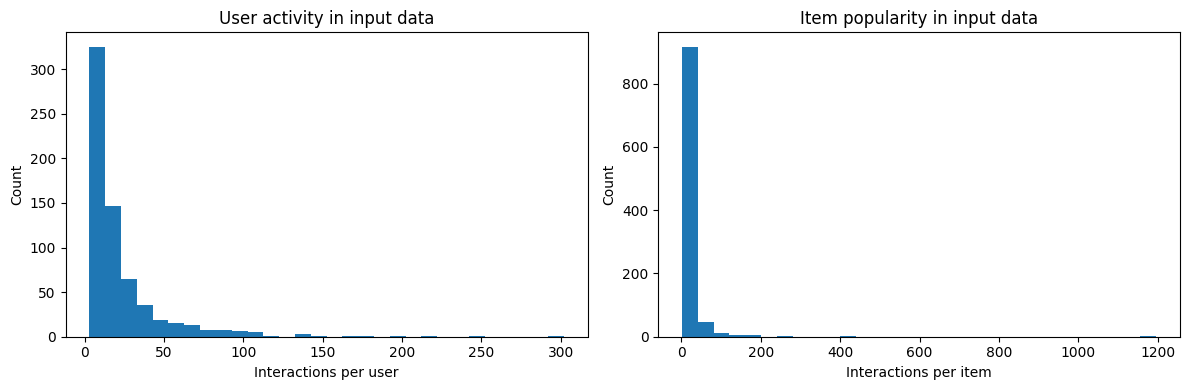

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(user_activity_input["n_interactions"], bins=30)
axes[0].set_title("User activity in input data")
axes[0].set_xlabel("Interactions per user")
axes[0].set_ylabel("Count")

axes[1].hist(item_popularity_input["n_interactions"], bins=30)
axes[1].set_title("Item popularity in input data")
axes[1].set_xlabel("Interactions per item")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 9. Per-iteration experiment summary

This table gives the minimum set of structural diagnostics:
- training interactions
- unique users/items seen in the iteration dataset
- number of recommendations
- recommendation coverage
- number of accepted items
- acceptance ratio
- embedding shapes

In [151]:
rows = []

for t in available_iterations:
    d = datasets_by_iter.get(t)
    r = topk_by_iter.get(t)
    a = accepted_by_iter.get(t)
    n = ndcg_by_iter.get(t)
    ue = user_emb_by_iter.get(t)
    ie = item_emb_by_iter.get(t)

    rows.append({
        "iteration": t,
        "dataset_rows": len(d) if d is not None else np.nan,
        "dataset_unique_users": d["user_id"].nunique() if d is not None and len(d) else np.nan,
        "dataset_unique_items": d["item_id"].nunique() if d is not None and len(d) else np.nan,
        "topk_rows": len(r) if r is not None else np.nan,
        "topk_unique_users": r["user_id"].nunique() if r is not None and len(r) else np.nan,
        "topk_unique_items": r["item_id"].nunique() if r is not None and len(r) else np.nan,
        "mean_recs_per_user": (len(r) / r["user_id"].nunique()) if r is not None and len(r) else np.nan,
        "accepted_rows": len(a) if a is not None else np.nan,
        "accepted_unique_users": a["user_id"].nunique() if a is not None and len(a) else np.nan,
        "accepted_unique_items": a["item_id"].nunique() if a is not None and len(a) else np.nan,
        "acceptance_ratio_vs_topk": (len(a) / len(r)) if (a is not None and r is not None and len(r)) else np.nan,
        "ndcg_users": n["user_id"].nunique() if n is not None and len(n) else np.nan,
        "mean_ndcg": n["ndcg_at_10"].mean() if n is not None and len(n) else np.nan,
        "user_embedding_shape": tuple(ue.shape) if ue is not None and hasattr(ue, "shape") else None,
        "item_embedding_shape": tuple(ie.shape) if ie is not None and hasattr(ie, "shape") else None,
    })

iteration_summary = pd.DataFrame(rows).sort_values("iteration")
display(iteration_summary)

,iteration,dataset_rows,dataset_unique_users,dataset_unique_items,topk_rows,topk_unique_users,topk_unique_items,mean_recs_per_user,accepted_rows,accepted_unique_users,accepted_unique_items,acceptance_ratio_vs_topk,ndcg_users,mean_ndcg,user_embedding_shape,item_embedding_shape
0,1,14620,655,991,6550,655,641,10.0,6550,655,641,1.0,655,0.594338,"(656, 256)","(992, 256)"
1,2,21169,655,991,6550,655,361,10.0,6550,655,361,1.0,655,0.395702,"(656, 256)","(992, 256)"
2,3,27718,655,991,6550,655,250,10.0,6550,655,250,1.0,655,0.418445,"(656, 256)","(992, 256)"
3,4,34267,655,991,6550,655,205,10.0,6550,655,205,1.0,655,0.477119,"(656, 256)","(992, 256)"
4,5,40816,655,991,6550,655,139,10.0,6550,655,139,1.0,655,0.564984,"(656, 256)","(992, 256)"


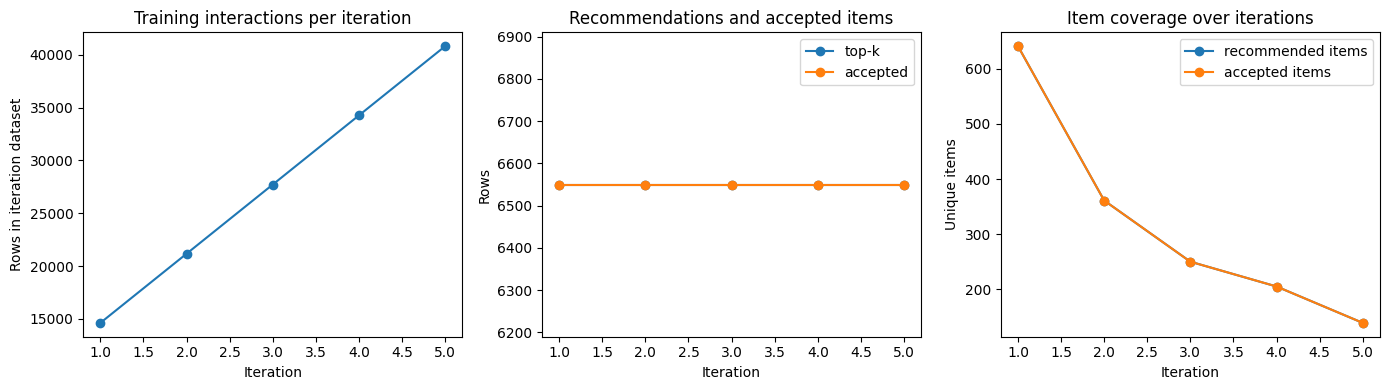

In [152]:
if not iteration_summary.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(iteration_summary["iteration"], iteration_summary["dataset_rows"], marker="o")
    axes[0].set_title("Training interactions per iteration")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Rows in iteration dataset")

    axes[1].plot(iteration_summary["iteration"], iteration_summary["topk_rows"], marker="o", label="top-k")
    axes[1].plot(iteration_summary["iteration"], iteration_summary["accepted_rows"], marker="o", label="accepted")
    axes[1].set_title("Recommendations and accepted items")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Rows")
    axes[1].legend()

    axes[2].plot(iteration_summary["iteration"], iteration_summary["topk_unique_items"], marker="o", label="recommended items")
    axes[2].plot(iteration_summary["iteration"], iteration_summary["accepted_unique_items"], marker="o", label="accepted items")
    axes[2].set_title("Item coverage over iterations")
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel("Unique items")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## 10. Recommendation-level basic statistics

In [153]:
if not topk_all.empty:
    rec_stats = (
        topk_all.groupby("iteration")
        .agg(
            n_rows=("item_id", "size"),
            n_users=("user_id", "nunique"),
            n_items=("item_id", "nunique"),
            min_rank=("rank", "min"),
            max_rank=("rank", "max"),
            mean_score=("score", "mean"),
            std_score=("score", "std"),
        )
        .reset_index()
    )
    display(rec_stats)

    per_user_rec_counts = (
        topk_all.groupby(["iteration", "user_id"])
        .size()
        .rename("n_recommendations")
        .reset_index()
    )

    display(per_user_rec_counts.head())

,iteration,n_rows,n_users,n_items,min_rank,max_rank,mean_score,std_score
0,1,6550,655,641,1,10,0.194166,0.076864
1,2,6550,655,361,1,10,0.255241,0.100813
2,3,6550,655,250,1,10,0.246117,0.075931
3,4,6550,655,205,1,10,0.268575,0.072747
4,5,6550,655,139,1,10,0.319936,0.073621


,iteration,user_id,n_recommendations
0,1,0,10
1,1,1,10
2,1,2,10
3,1,3,10
4,1,4,10


## 11. Accepted-song basic statistics

In [154]:
if not accepted_all.empty:
    accepted_stats = (
        accepted_all.groupby("iteration")
        .agg(
            n_rows=("item_id", "size"),
            n_users=("user_id", "nunique"),
            n_items=("item_id", "nunique"),
        )
        .reset_index()
    )
    display(accepted_stats)

    per_user_accept_counts = (
        accepted_all.groupby(["iteration", "user_id"])
        .size()
        .rename("n_accepted")
        .reset_index()
    )
    display(per_user_accept_counts.head())

,iteration,n_rows,n_users,n_items
0,1,6550,655,641
1,2,6550,655,361
2,3,6550,655,250
3,4,6550,655,205
4,5,6550,655,139


,iteration,user_id,n_accepted
0,1,0,10
1,1,1,10
2,1,2,10
3,1,3,10
4,1,4,10


## 12. Iteration-wise user statistics

For each iteration dataset, compute per-user activity and compare it with recommendation and acceptance counts.

In [155]:
user_iteration_stats = (
    datasets_all.groupby(["iteration", "user_id"])
    .size()
    .rename("dataset_interactions")
    .reset_index()
    if not datasets_all.empty else pd.DataFrame(columns=["iteration", "user_id", "dataset_interactions"])
)

if not topk_all.empty:
    user_iteration_stats = user_iteration_stats.merge(
        topk_all.groupby(["iteration", "user_id"]).size().rename("n_recommendations").reset_index(),
        on=["iteration", "user_id"],
        how="outer",
    )

if not accepted_all.empty:
    user_iteration_stats = user_iteration_stats.merge(
        accepted_all.groupby(["iteration", "user_id"]).size().rename("n_accepted").reset_index(),
        on=["iteration", "user_id"],
        how="outer",
    )

user_iteration_stats = user_iteration_stats.merge(demographics, on="user_id", how="left")

if not ndcg_all.empty:
    user_iteration_stats = user_iteration_stats.merge(
        ndcg_all[["iteration", "user_id", "ndcg_at_10"]],
        on=["iteration", "user_id"],
        how="left",
    )

display(user_iteration_stats.head())

,iteration,user_id,dataset_interactions,n_recommendations,n_accepted,country,age,gender,ndcg_at_10
0,1,0,16,10,10,NL,37,m,0.234639
1,1,1,12,10,10,FI,35,m,0.613147
2,1,2,9,10,10,UK,42,m,0.000000
3,1,3,33,10,10,US,27,m,0.636682
4,1,4,3,10,10,DE,27,m,1.000000


In [156]:
if not user_iteration_stats.empty:
    summary_user_iteration = (
        user_iteration_stats.groupby("iteration")
        .agg(
            users=("user_id", "nunique"),
            mean_dataset_interactions=("dataset_interactions", "mean"),
            median_dataset_interactions=("dataset_interactions", "median"),
            mean_recommendations=("n_recommendations", "mean"),
            mean_accepted=("n_accepted", "mean"),
            mean_ndcg=("ndcg_at_10", "mean"),
        )
        .reset_index()
    )
    display(summary_user_iteration.round(4))

,iteration,users,mean_dataset_interactions,median_dataset_interactions,mean_recommendations,mean_accepted,mean_ndcg
0,1,655,22.3206,13.0,10.0,10.0,0.5943
1,2,655,32.3191,23.0,10.0,10.0,0.3957
2,3,655,42.3176,33.0,10.0,10.0,0.4184
3,4,655,52.3160,43.0,10.0,10.0,0.4771
4,5,655,62.3145,53.0,10.0,10.0,0.5650


## 13. Iteration-wise item statistics

This exposes early signs of concentration or reinforcement:
- how many distinct items appear in the dataset
- how many receive recommendations
- how many are accepted
- whether activity accumulates on a narrower subset

In [157]:
item_iteration_stats = (
    datasets_all.groupby(["iteration", "item_id"])
    .size()
    .rename("dataset_frequency")
    .reset_index()
    if not datasets_all.empty else pd.DataFrame(columns=["iteration", "item_id", "dataset_frequency"])
)

if not topk_all.empty:
    item_iteration_stats = item_iteration_stats.merge(
        topk_all.groupby(["iteration", "item_id"]).size().rename("recommendation_frequency").reset_index(),
        on=["iteration", "item_id"],
        how="outer",
    )

if not accepted_all.empty:
    item_iteration_stats = item_iteration_stats.merge(
        accepted_all.groupby(["iteration", "item_id"]).size().rename("accepted_frequency").reset_index(),
        on=["iteration", "item_id"],
        how="outer",
    )

item_iteration_stats = item_iteration_stats.merge(tracks, on="item_id", how="left")
display(item_iteration_stats.head())

,iteration,item_id,dataset_frequency,recommendation_frequency,accepted_frequency,artist,title,artist_country,artist_gender
0,1,0,3,1.0,1.0,shakewell,.38 Special,US,Male
1,1,1,5,2.0,2.0,Ten Typ Mes,100 wymówek,PL,Male
2,1,2,5,3.0,3.0,Marilyn Manson,1996,US,Male
3,1,3,5,NaN,NaN,Tinashe,2 On,US,Female
4,1,4,2,NaN,NaN,Ann Lee,2 Times,IT,Female


In [158]:
if not item_iteration_stats.empty:
    item_summary = (
        item_iteration_stats.groupby("iteration")
        .agg(
            items=("item_id", "nunique"),
            mean_dataset_frequency=("dataset_frequency", "mean"),
            median_dataset_frequency=("dataset_frequency", "median"),
            mean_recommendation_frequency=("recommendation_frequency", "mean"),
            mean_accepted_frequency=("accepted_frequency", "mean"),
        )
        .reset_index()
    )
    display(item_summary.round(4))

,iteration,items,mean_dataset_frequency,median_dataset_frequency,mean_recommendation_frequency,mean_accepted_frequency
0,1,991,14.7528,5.0,10.2184,10.2184
1,2,991,21.3613,6.0,18.1440,18.1440
2,3,991,27.9697,6.0,26.2000,26.2000
3,4,991,34.5782,6.0,31.9512,31.9512
4,5,991,41.1867,6.0,47.1223,47.1223


## 14. Metadata sanity checks

These checks are simple but important before any bias analysis.

In [159]:
country_counts = demographics["country"].value_counts(dropna=False).rename_axis("country").reset_index(name="n_users")
gender_counts = demographics["gender"].value_counts(dropna=False).rename_axis("gender").reset_index(name="n_users")
artist_country_counts = tracks["artist_country"].value_counts(dropna=False).rename_axis("artist_country").reset_index(name="n_items")
artist_gender_counts = tracks["artist_gender"].value_counts(dropna=False).rename_axis("artist_gender").reset_index(name="n_items")

display(country_counts.head(15))
display(gender_counts)
display(artist_country_counts.head(15))
display(artist_gender_counts)

,country,n_users
0,BR,84
1,US,81
2,UK,57
3,PL,56
4,RU,46
5,DE,45
6,SE,24
7,FI,22
8,NL,18
9,CA,15


,gender,n_users
0,m,518
1,f,137


,artist_country,n_items
0,US,464
1,UK,187
2,CA,60
3,BR,47
4,AU,31
5,SE,17
6,FR,17
7,IT,15
8,MX,15
9,IE,13


,artist_gender,n_items
0,Male,555
1,Female,418
2,Non-binary,16
3,Other,2


## 15. Embedding inventory and basic diagnostics

At this stage we do not yet interpret geometry. We only verify:
- dimensionality
- user/item count consistency
- simple norm summaries

In [160]:
embedding_rows = []

for t in available_iterations:
    ue = user_emb_by_iter.get(t)
    ie = item_emb_by_iter.get(t)

    if ue is not None:
        ue_np = ue.detach().cpu().numpy() if hasattr(ue, "detach") else np.asarray(ue)
        user_norms = np.linalg.norm(ue_np, axis=1)
        embedding_rows.append({
            "iteration": t,
            "embedding_type": "user",
            "n_entities": ue_np.shape[0],
            "embedding_dim": ue_np.shape[1],
            "mean_norm": user_norms.mean(),
            "std_norm": user_norms.std(),
        })

    if ie is not None:
        ie_np = ie.detach().cpu().numpy() if hasattr(ie, "detach") else np.asarray(ie)
        item_norms = np.linalg.norm(ie_np, axis=1)
        embedding_rows.append({
            "iteration": t,
            "embedding_type": "item",
            "n_entities": ie_np.shape[0],
            "embedding_dim": ie_np.shape[1],
            "mean_norm": item_norms.mean(),
            "std_norm": item_norms.std(),
        })

embedding_summary = pd.DataFrame(embedding_rows)
display(embedding_summary.round(4))

,iteration,embedding_type,n_entities,embedding_dim,mean_norm,std_norm
0,1,user,656,256,1.0560,0.1853
1,1,item,992,256,0.8544,0.1967
2,2,user,656,256,1.0901,0.1832
3,2,item,992,256,0.8723,0.2027
4,3,user,656,256,1.0162,0.1470
5,3,item,992,256,0.8132,0.1601
6,4,user,656,256,0.9771,0.1176
7,4,item,992,256,0.7829,0.1307
8,5,user,656,256,0.9794,0.1076
9,5,item,992,256,0.7804,0.1260


In [161]:
t = available_iterations[0]
ue = user_emb_by_iter.get(t)
ie = item_emb_by_iter.get(t)

print("type(user emb):", type(ue))
print("type(item emb):", type(ie))

if ue is not None:
    print("user emb repr:", repr(ue)[:500])

if ie is not None:
    print("item emb repr:", repr(ie)[:500])

type(user emb): <class 'torch.Tensor'>
type(item emb): <class 'torch.Tensor'>
user emb repr: tensor([[-0.0492, -0.0506, -0.0088,  ..., -0.0280, -0.0367,  0.0327],
        [-0.0475, -0.0160, -0.0329,  ...,  0.0288,  0.1108,  0.0074],
        [ 0.0391, -0.0054,  0.0257,  ..., -0.0654, -0.0736, -0.0079],
        ...,
        [ 0.0366, -0.0835, -0.0329,  ...,  0.0098,  0.0393, -0.0981],
        [ 0.0273,  0.0615,  0.0586,  ..., -0.0939,  0.0764, -0.0371],
        [ 0.0320, -0.0234,  0.0056,  ...,  0.0462,  0.0863,  0.0087]])
item emb repr: tensor([[-0.0228, -0.0443, -0.0115,  ..., -0.0552, -0.0523,  0.0722],
        [-0.0931, -0.0576,  0.0593,  ..., -0.0174,  0.0358,  0.0310],
        [-0.1038,  0.1390,  0.0543,  ...,  0.0590,  0.0344,  0.1127],
        ...,
        [ 0.0874, -0.0489,  0.0544,  ..., -0.0526, -0.0919,  0.0144],
        [ 0.0236, -0.0440, -0.0190,  ..., -0.0291, -0.0646,  0.0550],
        [ 0.0022,  0.0133,  0.0122,  ...,  0.0805, -0.0037,  0.0271]])


In [162]:
from pathlib import Path

print("OUTPUT_DIR:", output_dir)
print()

for t in available_iterations:
    user_fp = output_dir / f"iteration_{t}_user_embedding.pt"
    item_fp = output_dir / f"iteration_{t}_item_embedding.pt"
    print(f"iteration {t}")
    print("  user exists:", user_fp.exists(), "|", user_fp)
    print("  item exists:", item_fp.exists(), "|", item_fp)

OUTPUT_DIR: C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\output

iteration 1
  user exists: True | C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\output\iteration_1_user_embedding.pt
  item exists: True | C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\output\iteration_1_item_embedding.pt
iteration 2
  user exists: True | C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\output\iteration_2_user_embedding.pt
  item exists: True | C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\output\iteration_2_item_embedding.pt
iteration 3
  user exists: True | C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\output\iteration_3_user_embedding.pt
  item exists: True | C:\Users\Raphael\PhD\Research\26\RECVIS\Simulations4VIS\experiments\babyLFM2b1k\output\iteration_3_item_embedding.pt
iteration 4
  user exists: Tru

In [163]:

import numpy as np

t = available_iterations[0]

user_fp = output_dir / f"iteration_{t}_user_embedding.pt"
item_fp = output_dir / f"iteration_{t}_item_embedding.pt"

obj_u = torch.load(user_fp, map_location="cpu")
obj_i = torch.load(item_fp, map_location="cpu")

print("user object type:", type(obj_u))
print("item object type:", type(obj_i))

if hasattr(obj_u, "shape"):
    print("user shape:", obj_u.shape)
else:
    print("user preview:", repr(obj_u)[:1000])

if hasattr(obj_i, "shape"):
    print("item shape:", obj_i.shape)
else:
    print("item preview:", repr(obj_i)[:1000])

user object type: <class 'torch.Tensor'>
item object type: <class 'torch.Tensor'>
user shape: torch.Size([656, 256])
item shape: torch.Size([992, 256])


In [164]:
print(torch)
print(type(torch))


<module 'torch' from 'c:\\Users\\Raphael\\miniconda3\\Lib\\site-packages\\torch\\__init__.py'>
<class 'module'>


## 16. External metric files

These files are already aggregated and remain useful as a compact reference layer.  
They should not replace the raw analysis, but they are useful for consistency checks.

In [165]:
metrics = load_csv_if_exists(EXPERIMENT_ROOT / "metrics.csv")
if metrics is None and FALLBACK_ROOT is not None:
    metrics = load_csv_if_exists(Path(FALLBACK_ROOT) / "metrics.csv")

user_based_metrics = load_csv_if_exists(EXPERIMENT_ROOT / "user_based_metrics.csv")
if user_based_metrics is None and FALLBACK_ROOT is not None:
    user_based_metrics = load_csv_if_exists(Path(FALLBACK_ROOT) / "user_based_metrics.csv")

baselines = load_csv_if_exists(EXPERIMENT_ROOT / "baselines.csv")
if baselines is None and FALLBACK_ROOT is not None:
    baselines = load_csv_if_exists(Path(FALLBACK_ROOT) / "baselines.csv")

print("metrics            :", None if metrics is None else metrics.shape)
print("user_based_metrics :", None if user_based_metrics is None else user_based_metrics.shape)
print("baselines          :", None if baselines is None else baselines.shape)

if metrics is not None:
    display(metrics.head())
if user_based_metrics is not None:
    display(user_based_metrics.head())
if baselines is not None:
    display(baselines.head())

metrics            : (320, 16)
user_based_metrics : (3275, 18)
baselines          : (64, 4)


,user_id,model,choice_model,iteration,country,user_count,jsd,bin_jsd,us_proportion,local_proportion,interaction_us_proportion,interaction_local_proportion,interaction_jsd,interaction_bin_jsd,jsd_summarized,interaction_jsd_summarized
0,NaN,BPR,consume_all,1,global,655,0.624113,0.335066,0.501679,0.086565,0.503557,0.151436,0.0,0.0,0.321602,0.0
1,NaN,BPR,consume_all,1,AR,7,0.636409,0.271100,0.414286,0.014286,0.583333,0.023810,0.0,0.0,0.274232,0.0
2,NaN,BPR,consume_all,1,AT,6,0.740911,0.321661,0.433333,0.000000,0.313253,0.012048,0.0,0.0,0.282224,0.0
3,NaN,BPR,consume_all,1,AU,10,0.718847,0.374961,0.380000,0.030000,0.330218,0.099688,0.0,0.0,0.454457,0.0
4,NaN,BPR,consume_all,1,BE,5,0.718276,0.368242,0.420000,0.000000,0.607843,0.019608,0.0,0.0,0.352254,0.0


,user_id,model,choice_model,iteration,country,user_count,jsd,bin_jsd,us_proportion,local_proportion,interaction_us_proportion,interaction_local_proportion,interaction_jsd,interaction_bin_jsd,jsd_summarized,male_proportion,interaction_male_proportion,interaction_jsd_summarized
0,356,BPR,consume_all,1,US,1,0.829215,0.557923,0.3,0.1,0.687500,0.062500,0.0,0.0,0.146020,0.6,0.812500,0.0
1,129,BPR,consume_all,1,DK,1,0.730866,0.411333,0.3,0.0,0.166667,0.000000,0.0,0.0,0.321879,0.5,0.500000,0.0
2,202,BPR,consume_all,1,US,1,0.446054,0.038220,0.3,0.1,0.000000,0.444444,0.0,0.0,0.194643,0.5,0.222222,0.0
3,261,BPR,consume_all,1,RU,1,0.575347,0.517489,0.5,0.5,0.848485,0.848485,0.0,0.0,0.136462,0.1,0.939394,0.0
4,556,BPR,consume_all,1,BR,1,0.299084,0.870791,0.7,0.0,0.333333,0.666667,0.0,0.0,0.162719,0.4,1.000000,0.0


,country,us,local,other
0,global,0.503557,0.151436,0.443502
1,AR,0.583333,0.023810,0.392857
2,AT,0.313253,0.012048,0.674699
3,AU,0.330218,0.099688,0.570093
4,BE,0.607843,0.019608,0.372549


## 17. Compact analysis objects for later extension

The cell below stores a small dictionary of canonical tables.  
This is useful once the notebook grows and you want to keep the main objects explicit.

In [166]:
analysis_data = {
    "params": params,
    "demographics": demographics,
    "tracks": tracks,
    "dataset_input": dataset_input,
    "datasets_by_iter": datasets_by_iter,
    "topk_by_iter": topk_by_iter,
    "accepted_by_iter": accepted_by_iter,
    "ndcg_by_iter": ndcg_by_iter,
    "user_emb_by_iter": user_emb_by_iter,
    "item_emb_by_iter": item_emb_by_iter,
    "datasets_all": datasets_all,
    "topk_all": topk_all,
    "accepted_all": accepted_all,
    "ndcg_all": ndcg_all,
    "user_iteration_stats": user_iteration_stats,
    "item_iteration_stats": item_iteration_stats,
    "metrics": metrics,
    "user_based_metrics": user_based_metrics,
    "baselines": baselines,
}

sorted(analysis_data.keys())

['accepted_all',
 'accepted_by_iter',
 'baselines',
 'dataset_input',
 'datasets_all',
 'datasets_by_iter',
 'demographics',
 'item_emb_by_iter',
 'item_iteration_stats',
 'metrics',
 'ndcg_all',
 'ndcg_by_iter',
 'params',
 'topk_all',
 'topk_by_iter',
 'tracks',
 'user_based_metrics',
 'user_emb_by_iter',
 'user_iteration_stats']

## 18. Immediate next extension candidates

This notebook is intentionally limited to **loading + descriptive structural analysis**.  
The next non-redundant extensions are:

1. recommendation-origin analysis (US / local / other)
2. popularity-bin drift across iterations
3. user embedding projection and drift
4. recommendation acceptance coupling
5. group-wise disparity analysis by country / gender / activity

Those should be added **on top of** the canonical objects defined above rather than reloading files in separate notebooks.

In [176]:
pip install umap-learn

  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached numba-0.65.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached umap_learn-0.5.11-py3-none-any.whl (90 kB)
Using cached numba-0.65.0-cp313-cp313-win_amd64.whl (2.7 MB)
Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl (38.1 MB)
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   --------

In [ ]:
pip install scikit-learn

  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached numba-0.65.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached umap_learn-0.5.11-py3-none-any.whl (90 kB)
Using cached numba-0.65.0-cp313-cp313-win_amd64.whl (2.7 MB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   --------------------------------------

ERROR: Could not install packages due to an OSError: [WinError 32] Der Prozess kann nicht auf die Datei zugreifen, da sie von einem anderen Prozess verwendet wird: 'C:\\Users\\Raphael\\AppData\\Local\\Temp\\pip-unpack-y5hh525e\\llvmlite-0.47.0-cp313-cp313-win_amd64.whl'
Consider using the `--user` option or check the permissions.



  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------

ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\Raphael\miniconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "c:\Users\Raphael\miniconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "c:\Users\Raphael\miniconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "c:\Users\Raphael\miniconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 100, in read
    data: bytes = self.__fp.read(amt)
                  ~~~~~~~~~~~~~~^^^^^
  File "c:\Users\Raphael\miniconda3\Lib\http\client.py", line 484, in read
    s = self.fp.read(amt)
  File "c:\Users\Raphael\miniconda3\Lib\socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~

ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\Raphael\miniconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "c:\Users\Raphael\miniconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "c:\Users\Raphael\miniconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "c:\Users\Raphael\miniconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 100, in read
    data: bytes = self.__fp.read(amt)
                  ~~~~~~~~~~~~~~^^^^^
  File "c:\Users\Raphael\miniconda3\Lib\http\client.py", line 484, in read
    s = self.fp.read(amt)
  File "c:\Users\Raphael\miniconda3\Lib\socket.py", line 719, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -------------------------------

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    import umap.umap_ as umap
except ImportError:
    import umap

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

c:\Users\Raphael\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [178]:
def tensor_to_numpy(x):
    if x is None:
        return None
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

user_emb_np_by_iter = {}
item_emb_np_by_iter = {}

for t in available_iterations:
    user_emb_np_by_iter[t] = tensor_to_numpy(user_emb_by_iter.get(t))
    item_emb_np_by_iter[t] = tensor_to_numpy(item_emb_by_iter.get(t))

embedding_rows = []

for t in available_iterations:
    ue = user_emb_np_by_iter.get(t)
    ie = item_emb_np_by_iter.get(t)

    if ue is not None:
        embedding_rows.append({
            "iteration": t,
            "embedding_type": "user",
            "n_entities": int(ue.shape[0]),
            "embedding_dim": int(ue.shape[1]),
            "mean_l2_norm": float(np.linalg.norm(ue, axis=1).mean()),
            "std_l2_norm": float(np.linalg.norm(ue, axis=1).std()),
        })

    if ie is not None:
        embedding_rows.append({
            "iteration": t,
            "embedding_type": "item",
            "n_entities": int(ie.shape[0]),
            "embedding_dim": int(ie.shape[1]),
            "mean_l2_norm": float(np.linalg.norm(ie, axis=1).mean()),
            "std_l2_norm": float(np.linalg.norm(ie, axis=1).std()),
        })

embedding_summary = pd.DataFrame(embedding_rows)
display(embedding_summary.round(4))

,iteration,embedding_type,n_entities,embedding_dim,mean_l2_norm,std_l2_norm
0,1,user,656,256,1.0560,0.1853
1,1,item,992,256,0.8544,0.1967
2,2,user,656,256,1.0901,0.1832
3,2,item,992,256,0.8723,0.2027
4,3,user,656,256,1.0162,0.1470
5,3,item,992,256,0.8132,0.1601
6,4,user,656,256,0.9771,0.1176
7,4,item,992,256,0.7829,0.1307
8,5,user,656,256,0.9794,0.1076
9,5,item,992,256,0.7804,0.1260


In [181]:
# --- canonical user table based on the actual scaffold variables ---

base_interactions = dataset_input.copy().rename(columns={
    "user_id:token": "user_id",
    "item_id:token": "item_id"
})

# input-side user activity
user_activity = (
    base_interactions.groupby("user_id")
    .size()
    .rename("n_input_interactions")
    .reset_index()
)

# iteration-1 NDCG
if 1 in ndcg_by_iter:
    ndcg_iter1 = ndcg_by_iter[1].copy()
else:
    ndcg_iter1 = pd.DataFrame(columns=["user_id", "ndcg_at_10"])

ndcg_iter1 = ndcg_iter1.rename(columns={c: c.strip() for c in ndcg_iter1.columns})

# be robust to possible naming variants
if "ndcg@10" in ndcg_iter1.columns and "ndcg_at_10" not in ndcg_iter1.columns:
    ndcg_iter1 = ndcg_iter1.rename(columns={"ndcg@10": "ndcg_at_10"})

# iteration-1 recommendation count
if 1 in topk_by_iter:
    topk_iter1 = topk_by_iter[1].copy()
else:
    topk_iter1 = pd.DataFrame(columns=["user_id", "item_id", "rank", "score"])

topk_iter1 = topk_iter1.rename(columns={
    "user_id:token": "user_id",
    "item_id:token": "item_id"
})

topk_count_iter1 = (
    topk_iter1.groupby("user_id")
    .size()
    .rename("n_recommended_iter1")
    .reset_index()
)

# build canonical user table
df_users = demographics.copy()

df_users = df_users.merge(user_activity, on="user_id", how="left")

if {"user_id", "ndcg_at_10"}.issubset(ndcg_iter1.columns):
    df_users = df_users.merge(
        ndcg_iter1[["user_id", "ndcg_at_10"]],
        on="user_id",
        how="left"
    )

df_users = df_users.merge(topk_count_iter1, on="user_id", how="left")

df_users["n_input_interactions"] = df_users["n_input_interactions"].fillna(0).astype(int)
df_users["n_recommended_iter1"] = df_users["n_recommended_iter1"].fillna(0).astype(int)

display(df_users.head())
print(df_users.shape)

,country,age,gender,user_id,n_input_interactions,ndcg_at_10,n_recommended_iter1
0,NL,37,m,0,16,0.234639,10
1,FI,35,m,1,12,0.613147,10
2,UK,42,m,2,9,0.000000,10
3,US,27,m,3,33,0.636682,10
4,DE,27,m,4,3,1.000000,10


(655, 7)
